<a href="https://www.nvidia.com/dli"> <img src="https://github.com/YKochura/ac-kpi/blob/main/figures/lec8/DLI%20Header.png?raw=true" alt="Header" style="width: 400px;"/> </a>

<a href="https://colab.research.google.com/github/YKochura/ac-kpi/blob/main/tutor/Introduction%2Bto%2BCUDA%2BPython%2Bwith%2BNumba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вступ до CUDA Python з Numba

Обчислювальна платформа **[CUDA](https://en.wikipedia.org/wiki/CUDA)** забезпечує значне прискорення застосунків, надаючи розробникам можливість виконувати код паралельно на тисячах ядер GPU NVIDIA.

**[Numba](http://numba.pydata.org/)** &mdash; це Python-компілятор функцій з JIT-компіляцією (компіляція «на льоту»), що надає простий інтерфейс для прискорення Python-функцій, орієнтованих на числові обчислення. Numba є дуже привабливим варіантом для Python-розробників, які прагнуть прискорити свої застосунки за допомогою GPU без необхідності писати код на C/C++, — особливо для тих розробників, які вже виконують обчислювально інтенсивні операції з масивами NumPy. Numba може використовуватися для прискорення Python-функцій як на CPU, так і на GPU.
 ****




Спочатку ми розберемося, як використовувати Numba для компіляції функцій на CPU &mdash; це допоможе зрозуміти, як працює компілятор зсередини. Після цього перейдемо до головного: навчимося прискорювати поелементні операції з масивами NumPy за допомогою GPU, а також розглянемо, як ефективно передавати дані між CPU і GPU.

Після цієї лекції ви вже зможете самостійно переносити Python-код з поелементними операціями над NumPy-масивами на GPU &mdash; і відчути різницю в продуктивності.



## Мета лекції

> **Метою цієї лекції** є ознайомлення з фундаментальними техніками GPU-прискорених обчислень в Python-застосунках з використанням Numba.

Після завершення цієї лекції ви зможете:

- Використовувати Numba для компіляції Python-функцій на CPU.
- Розуміти, як Numba компілює Python-функції.
- Прискорювати за допомогою GPU NumPy ufuncs.
- Прискорювати власноруч написані векторизовані функції на GPU.
- Оптимізувати передачу даних між CPU-хостом і GPU-пристроєм.


## Numba


Numba — це JIT-компілятор (**just-in-time**), **спеціалізований за типами**, **компілятор функцій**, який вміє прискорювати **числові обчислення** як на CPU, так і на GPU.  

 * **Компілятор функцій **. Numba працює не з цілим застосунком, а лише з окремими функціями. Numba не замінює Python-інтерпретатор, а просто «покращує» конкретну функцію, роблячи її швидшою. Решта вашого коду працює як зазвичай.
 * **Спеціалізація за типами**. Звичайні Python-функції розраховані на будь-які типи даних, що й робить їх гнучкими, але повільними. Numba вирішує цю проблему інакше: він генерує окрему оптимізовану реалізацію під кожен конкретний набір типів аргументів. Тобто замість універсального, але повільного рішення Ви отримуєте швидке і точне.
 * **Just-in-time (JIT)**. Компіляція відбувається не заздалегідь, а в момент першого виклику функції. Саме тоді Numba «бачить» реальні типи аргументів і компілює під них. Це також означає, що Numba чудово працює прямо в Jupyter Notebook — без жодних додаткових налаштувань.
 * **Числова орієнтованість**. Numba найкраще працює з числовими типами: `int`, `float`, `complex` і особливо добре дружить з масивами NumPy. Якщо ж у вашому коді багато роботи з рядками (`str`) &mdash; Numba тут навряд чи допоможе, на GPU зокрема. Але якщо Ви рахуєте, трансформуєте масиви чисел &mdash; Numba саме для вас.

## Вимоги для використання Numba

Numba підтримує широкий спектр операційних систем:

 * Windows 7 і новіші, 32 і 64-біт
 * macOS 10.9 і новіші, 64-біт
 * Linux (більшість дистрибутивів >= RHEL 5), 32 і 64-біт

та версії Python:

 * Python 2.7, >3.4
 * NumPy 1.10  і новіші

а також широкий спектр апаратного забезпечення:

* x86, x86_64/AMD64 CPUs
* NVIDIA CUDA GPUs (Compute capability 3.0 і новіші, CUDA 8.0 і новіші)
* AMD GPUs (експериментальна підтримка)
* ARM (експериментальна підтримка)


In [ ]:
import platform

print("Операційна система:", platform.system())
print("Версія ОС:", platform.release())
print("Архітектура:", platform.machine())
print("Повна інформація:", platform.platform())

Операційна система: Linux
Версія ОС: 6.6.113+
Архітектура: x86_64
Повна інформація: Linux-6.6.113+-x86_64-with-glibc2.35


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


## CUDA C/C++ vs. Numba vs. pyCUDA

Numba &mdash; далеко не єдиний спосіб програмувати з CUDA. Найпоширенішим підходом залишається написання коду з використанням мовних розширень CUDA C/C++. У світі Python альтернативою Numba є бібліотека [pyCUDA](https://documen.tician.de/pycuda/). У цій лекції ми зосередимося саме на Numba, але перед початком варто коротко порівняти всі три підходи — просто щоб краще розуміти загальну картину.

**CUDA C/C++**:
- Найпоширеніший, продуктивний і гнучкий спосіб використання CUDA
- Прискорює застосунки на C/C++

**pyCUDA**:
- Надає доступ до повного API CUDA C/C++
- Найпродуктивніший CUDA-варіант для Python
- Потребує написання C-коду всередині Python і, як правило, значних змін у коді

**Numba**:
- Потенційно менш продуктивна ніж pyCUDA
- Поки що не надає доступу до повного API CUDA C/C++
- Проте забезпечує значне прискорення, часто з мінімальними змінами в коді
- Дозволяє писати код безпосередньо на Python
- Також оптимізує Python-код для CPU

## Перші кроки: компіляція для CPU

Як ви пам'ятаєте, Numba може оптимізувати код як для **CPU**, так і для GPU. Для початку, перш ніж переходити до GPU-прискорення, напишемо нашу першу Numba-функцію та скомпілюємо її для CPU. Це дасть нам легкий вхід у синтаксис Numba, а трохи пізніше ми зможемо порівняти продуктивність CPU-оптимізованого коду з GPU-прискореним.

Компілятор Numba зазвичай активується за допомогою [**декоратора функції**](https://en.wikipedia.org/wiki/Python_syntax_and_semantics#Decorators) &mdash; це спеціальний модифікатор, який трансформує функцію з дуже простим синтаксисом. Тут ми використаємо декоратор CPU-компіляції від Numba &mdash; `@jit`:

In [ ]:
from numba import jit
import math

# This is the function decorator syntax and is equivalent to `hypot = jit(hypot)`.
# The Numba compiler is just a function you can call whenever you want!
@jit
def hypot(x, y):
    # Implementation from https://en.wikipedia.org/wiki/Hypot
    x = abs(x);
    y = abs(y);
    t = min(x, y);
    x = max(x, y);
    t = t / x;
    return x * math.sqrt(1+t*t)

Обчислимо гіпотенузу:

In [ ]:
hypot(3.0, 4.0)

5.0

Трохи пізніше ми детальніше розберемо, що відбувається під час виклику `hypot`. Але зараз головне розуміти ось що: при першому виклику функції Numba автоматично компілює її у машинний код, оптимізований під тип вхідних даних — у нашому випадку під `float`.

Також Numba зберігає оригінальну Python-реалізацію функції в атрибуті `.py_func` — це дозволяє нам викликати незмінений Python-код і переконатися, що обидві версії дають однаковий результат:

In [ ]:
hypot.py_func(3.0, 4.0)

5.0

### Вимірювання продуктивності

Важлива частина роботи з Numba — це перевірка того, чи дійсно код став швидшим. Найзручніший спосіб зробити це в Jupyter Notebook — використати  [магічну функцію `%timeit` ](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit). Спочатку виміряємо швидкість оригінального Python-коду:


In [ ]:
%timeit hypot.py_func(3.0, 4.0)

The slowest run took 4.61 times longer than the fastest. This could mean that an intermediate result is being cached.
1.26 µs ± 477 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


Магічна функція `%timeit` запускає код багато разів, щоб отримати точну оцінку часу виконання. За замовчуванням вона повертає найкращий результат — це зменшує ймовірність того, що випадкові фонові процеси вплинуть на вимірювання. Підхід "найкраще з 3" також гарантує, що час компіляції при першому виклику не спотворить результати:

In [ ]:
%timeit hypot(3.0, 4.0)

Numba впоралася досить непогано. Результат явно швидший за чистий Python. Звісно, функція `hypot` вже є у стандартному модулі Python — цікаво порівняти, як вони співвідносяться:


In [ ]:
%timeit math.hypot(3.0, 4.0)

Вбудована функція Python виявилася навіть швидшою за Numba! Це пояснюється тим, що Numba додає певні накладні витрати на кожен виклик функції — і вони більші, ніж у самого Python. Для дуже швидких функцій, як у нашому випадку, це відчутно.

До речі, якщо викликати одну Numba-функцію з іншої — накладні витрати мінімальні, а іноді компілятор взагалі вбудовує одну функцію в іншу і витрат немає зовсім.

**Висновок:**  завжди вимірюйте продуктивність своїх функцій — лише так можна переконатися чи дійсно є прискорення.


### Приклад 2:  використання Numba для компіляції функції для CPU

Наступна функція використовує [метод Монте-Карло](https://academo.org/demos/estimating-pi-monte-carlo/) для обчислення числа Pi (вихідний код з домашньої сторінки [Numba homepage](http://numba.pydata.org/)).

In [ ]:
nsamples = 1000000

In [ ]:
import random
# Import Numba's just-in-time compiler function
from numba import jit

# Use the Numba compiler to compile this function
@jit
def monte_carlo_pi(nsamples):
    acc = 0
    for i in range(nsamples):
        x = random.random()
        y = random.random()
        if (x**2 + y**2) < 1.0:
            acc += 1
    return 4.0 * acc / nsamples

In [ ]:
monte_carlo_pi(nsamples)

In [ ]:
%timeit monte_carlo_pi(nsamples)

In [ ]:
%timeit monte_carlo_pi.py_func(nsamples)

## Як працює Numba?

Тепер, коли ви вже трохи попрактикувалися з компілятором Numba, давайте розберемося, що відбувається всередині. Під час першого виклику нашої Numba-функції `hypot` запускається наступний процес:


![Numba Flowchart](https://raw.githubusercontent.com/YKochura/ac-kpi/refs/heads/main/figures/lec8/numba_flowchart.png "The compilation process")

Результат визначення типів можна переглянути за допомогою методу `.inspect_types()`, який виводить анотовану версію вихідного коду:

In [ ]:
hypot.inspect_types()

Зверніть увагу, що назви типів у Numba відповідають [типам NumPy](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.types.html). Наприклад, звичайний Python `float` — це `float64` (в інших мовах його називають "double precision").

Слідкувати за типами даних особливо важливо у GPU-коді, адже продуктивність обчислень з `float32` і `float64` може суттєво відрізнятися залежно від GPU. Якщо ваш алгоритм дає правильні результати з `float32` — краще використовуйте саме його, оскільки перехід на `float64` може значно сповільнити виконання функції.

## Режими object та nopython

Numba не може скомпілювати весь Python-код. Деякі функції не мають Numba-реалізації, а деякі типи даних Python взагалі не підлягають ефективній компіляції — принаймні поки що. Наприклад, Numba наразі не підтримує словники (`dict`). Давайте спробуємо скомпілювати код, який Numba ще не вміє обробляти:

In [ ]:
@jit
def cannot_compile(x):
    return x['key']

cannot_compile(dict(key='value'))

Щоб примусово увімкнути режим `nopython` — передайте аргумент `nopython` до декоратора:

In [ ]:
@jit(nopython=True)
def cannot_compile(x):
    return x['key']

cannot_compile(dict(key='value'))

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
non-precise type pyobject
During: typing of argument at /tmp/ipykernel_6730/2364033852.py (1)

File "../tmp/ipykernel_6730/2364033852.py", line 1:
<source missing, REPL/exec in use?> 

This error may have been caused by the following argument(s):
- argument 0: Cannot determine Numba type of <class 'dict'>


При спробі скомпілювати функцію Numba видає помилку. Якщо прогорнути повідомлення про помилку до кінця, можна побачити рядок, який описує конкретну причину проблеми:
```
- argument 0: cannot determine Numba type of <class 'dict'>
```

Numba також надає декоратор `njit`, який є псевдонімом для `jit(nopython=True)`:

In [ ]:
from numba import njit

@njit
def cannot_compile(x):
    return x['key']

cannot_compile(dict(key='value'))

Для повного переліку підтримуваних Python-конструкцій зверніться до [документації Numba](https://numba.pydata.org/numba-doc/dev/reference/pysupported.html).

## Вступ до Numba для GPU за допомогою універсальних функцій NumPy (ufunc)

Ми розпочнемо вивчення GPU-програмування в Numba з того, як компілювати [універсальні функції NumPy (або ufunc)](https://docs.scipy.org/doc/numpy-1.15.1/reference/ufuncs.html) для GPU.


Найважливіше, що слід знати на початку GPU-програмування — GPU-залізо спроектовано для паралелізму даних. Максимальна продуктивність досягається тоді, коли GPU одночасно виконує однакові операції над великою кількістю елементів.

Універсальні функції NumPy виконують одну й ту саму операцію над кожним елементом масиву — це природньо паралельна за даними операція, тому вони добре пасують для GPU-програмування.

## Огляд універсальних функцій NumPy (ufunc)

Якщо ви не знайомі з ufunc або давно не працювали з ними — ось [короткий огляд](https://numpy.org/doc/stable/reference/ufuncs.html#ufunc).

У NumPy існує концепція універсальних функцій («ufunc») — це функції, які приймають масиви NumPy довільної розмірності або скаляри та обробляють їх поелементно.

Для прикладу розглянемо ufunc add з NumPy, щоб продемонструвати базовий механізм роботи ufunc:

In [1]:
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

np.add(a, b) # Returns a new NumPy array resulting from adding every element in `a` to every element in `b`

array([11, 22, 33, 44])

Ufunc також можуть поєднувати скаляри з масивами:

In [2]:
np.add(a, 100) # Returns a new NumPy array resulting from adding 100 to every element in `a`

array([101, 102, 103, 104])

Масиви різної, але сумісної розмірності також можна поєднувати за допомогою техніки під назвою [broadcasting](https://docs.scipy.org/doc/numpy-1.15.0/user/basics.broadcasting.html). Масив меншої розмірності буде розтиражовано відповідно до розмірності масиву вищої розмірності. За потреби ознайомтеся з документацією до [`numpy.arange`](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.arange.html) та [`numpy.ndarray.reshape`](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.ndarray.reshape.html):



In [3]:
c = np.arange(4*4).reshape((4,4))
print('c:', c)

np.add(b, c)

c: [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


array([[10, 21, 32, 43],
       [14, 25, 36, 47],
       [18, 29, 40, 51],
       [22, 33, 44, 55]])

## Створення ufunc для GPU

Numba має можливість створювати скомпільовані ufunc — зазвичай це непростий процес, що потребує написання коду на C. З Numba ви просто реалізуєте скалярну функцію, яка виконуватиметься над усіма вхідними даними, декоруєте її [`@vectorize`](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.vectorize.html), і Numba сама розбереться з правилами broadcasting. Для тих, хто знайомий з `vectorize` від NumPy, декоратор `vectorize` від Numba буде схожим.

У цьому першому прикладі ми використаємо декоратор `@vectorize`, щоб скомпілювати та оптимізувати ufunc для **CPU**.

In [4]:
from numba import vectorize

@vectorize
def add_ten(num):
    return num + 10 # This scalar operation will be performed on each element

In [5]:
nums = np.arange(10)
add_ten(nums) # pass the whole array into the ufunc, it performs the operation on each element

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

Ми створюємо ufunc, яка використовує CUDA на GPU — для цього потрібно вказати явну сигнатуру типів та встановити атрибут `target`. Аргумент сигнатури типів описує, які типи використовувати як для аргументів ufunc, так і для повернутого значення:
```python
'return_value_type(argument1_value_type, argument2_value_type, ...)'
```
Докладніше про [доступні типи](https://numba.pydata.org/numba-doc/dev/reference/types.html), а також про написання ufunc з кількома сигнатурами дивіться в [документації Numba](https://numba.pydata.org/numba-doc/dev/user/vectorize.html).

Ось простий приклад ufunc, яка буде скомпільована для GPU-пристрою з підтримкою CUDA. Вона приймає два значення типу `int64` та повертає також значення типу `int64`:

In [6]:
@vectorize(['int64(int64, int64)'], target='cuda') # Type signature and target are required for the GPU
def add_ufunc(x, y):
    return x + y

In [7]:
add_ufunc(a, b)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


array([11, 22, 33, 44])

Для такого простого виклику функції відбулося дуже багато всього! Numba автоматично:

* Скомпілювала CUDA-ядро для паралельного виконання операції ufunc над усіма вхідними елементами.
* Виділила пам'ять GPU для вхідних даних і результату.
* Скопіювала вхідні дані на GPU.
* Виконала CUDA-ядро (функцію GPU) з правильними розмірами ядра відповідно до розмірів вхідних даних.
* Скопіювала результат з GPU назад на CPU.
* Повернула результат у вигляді масиву NumPy на хості.

Порівняно з реалізацією на C, наведене вище є надзвичайно лаконічним.

Подивимось наскільки швидко працює наш простий приклад на GPU?

In [8]:
%timeit np.add(b, c)   # NumPy on CPU

1.38 µs ± 96.4 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [9]:
%timeit add_ufunc(b, c) # Numba on GPU

996 µs ± 537 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Ого, GPU набагато повільніший за CPU?? Наразі це очікувано, адже в цьому прикладі ми (навмисно) неправильно використали GPU. Розбір цих помилок допоможе зрозуміти, які задачі добре підходять для GPU-обчислень, а які краще залишити для CPU:

  * **Вхідні дані занадто малі:** GPU досягає продуктивності через паралелізм, обробляючи тисячі значень одночасно. Наші тестові вхідні дані містять лише 4 і 16 цілих чисел відповідно. Потрібен набагато більший масив, щоб GPU почав завантажуватися.
  * **Обчислення занадто прості:** Надсилання обчислення на GPU пов'язане зі значно більшими накладними витратами порівняно з викликом функції на CPU. Якщо обчислення не містить достатньої кількості математичних операцій (це часто називають «арифметичною інтенсивністю»), GPU витрачатиме більшу частину часу на очікування переміщення даних.
  * **Ми копіюємо дані на GPU і назад:** Хоча в деяких сценаріях витрати на копіювання даних можуть окупитися навіть для однієї функції, зазвичай краще запускати кілька GPU-операцій послідовно. У таких випадках доцільно надіслати дані на GPU і тримати їх там аж до завершення всієї обробки.
  * **Типи даних більші, ніж необхідно:** У прикладі використовується `int64`, хоча, мабуть, він нам не потрібен. Скалярний код з 32- і 64-бітними типами даних працює на CPU приблизно з однаковою швидкістю, і для цілочисельних типів різниця може бути несуттєвою, але 64-бітні числа з плаваючою комою можуть суттєво знижувати продуктивність на GPU залежно від його типу. Базові арифметичні операції з 64-бітними числами з плавуючою комою можуть бути від 2x (Tesla архітектури Pascal) до 24x (GeForce архітектури Maxwell) повільнішими за 32-бітні. На сучасніших GPU (Volta, Turing, Ampere) це може бути менш критично. NumPy за замовчуванням створює масиви з 64-бітними типами даних, тому важливо вказувати атрибут [`dtype`](https://docs.scipy.org/doc/numpy-1.14.0/reference/arrays.dtypes.html) або використовувати метод [`ndarray.astype()`](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.ndarray.astype.html), щоб обирати 32-бітні типи там, де вони потрібні.


З огляду на вищесказане, спробуємо приклад, який працює швидше на GPU: виконаємо операцію з набагато більшою арифметичною інтенсивністю, на значно більших вхідних даних та з використанням 32-бітного типу даних.

Зверніть увагу: не весь код NumPy працюватиме на GPU, і, як у наступному прикладі, нам знадобиться використовувати pi та exp з бібліотеки math замість NumPy. Детальну інформацію про підтримку NumPy на GPU дивіться в [документації Numba](https://numba.readthedocs.io/en/stable/).
  

In [10]:
import math # Note that for the CUDA target, we need to use the scalar functions from the math module, not NumPy

SQRT_2PI = np.float32((2*math.pi)**0.5)  # Precompute this constant as a float32.  Numba will inline it at compile time.

@vectorize(['float32(float32, float32, float32)'], target='cuda')
def gaussian_pdf(x, mean, sigma):
    '''Compute the value of a Gaussian probability density function at x with given mean and sigma.'''
    return math.exp(-0.5 * ((x - mean) / sigma)**2) / (sigma * SQRT_2PI)

In [11]:
import numpy as np
# Evaluate the Gaussian a million times!
x = np.random.uniform(-3, 3, size=1000000).astype(np.float32)
mean = np.float32(0.0)
sigma = np.float32(1.0)

# Quick test on a single element just to make sure it works
gaussian_pdf(x[0], 0.0, 1.0)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


array([0.23323317], dtype=float32)

In [12]:
import scipy.stats # for definition of gaussian distribution, so we can compare CPU to GPU time
norm_pdf = scipy.stats.norm
%timeit norm_pdf.pdf(x, loc=mean, scale=sigma)

32.3 ms ± 546 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
%timeit gaussian_pdf(x, mean, sigma)

4.4 ms ± 287 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Це досить значне покращення, навіть з урахуванням накладних витрат на копіювання всіх даних на GPU і назад. Ufunc, які використовують спеціальні функції (`exp`, `sin`, `cos` тощо) на великих наборах даних, працюють на GPU особливо добре.

Для повноти порівняння визначимо та виміряємо час роботи функції `gaussian_pdf`, оптимізованої Numba для CPU:

In [14]:
@vectorize
def cpu_gaussian_pdf(x, mean, sigma):
    '''Compute the value of a Gaussian probability density function at x with given mean and sigma.'''
    return math.exp(-0.5 * ((x - mean) / sigma)**2) / (sigma * SQRT_2PI)

In [15]:
%timeit cpu_gaussian_pdf(x, mean, sigma)

13.6 ms ± 1.87 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


Це набагато швидше за нескомпільовану CPU-версію, але значно повільніше за GPU-прискорену.

## CUDA Device Functions

Ufunc чудово підходять для поелементних операцій — це дуже поширена задача. Однак існує чимало функцій, які не вписуються в цю модель. Щоб компілювати функції для GPU, які не є поелементними векторизованими функціями, використовується `numba.cuda.jit`. Подивимось як використовувати `numba.cuda.jit` для декорування допоміжної функції, що викликається з GPU-прискореної ufunc — щоб не доводилося втискати всю логіку в одне визначення ufunc.

Зверніть увагу, що `polar_to_cartesian` нижче не потребує сигнатури типів, а також приймає два скалярні значення — на відміну від векторизованих ufunc, які ми використовували (як-от `polar_distance` нижче) і які очікують масиви NumPy як аргументи.

Аргумент `device=True` вказує, що декорована функція може бути викликана лише з функції, що виконується на GPU, але не з коду на стороні CPU:

In [17]:
from numba import cuda

@cuda.jit(device=True)
def polar_to_cartesian(rho, theta):
    x = rho * math.cos(theta)
    y = rho * math.sin(theta)
    return x, y

@vectorize(['float32(float32, float32, float32, float32)'], target='cuda')
def polar_distance(rho1, theta1, rho2, theta2):
    x1, y1 = polar_to_cartesian(rho1, theta1) # We can use device functions inside our GPU ufuncs
    x2, y2 = polar_to_cartesian(rho2, theta2)

    return ((x1 - x2)**2 + (y1 - y2)**2)**0.5

In [18]:
n = 1000000
rho1 = np.random.uniform(0.5, 1.5, size=n).astype(np.float32)
theta1 = np.random.uniform(-np.pi, np.pi, size=n).astype(np.float32)
rho2 = np.random.uniform(0.5, 1.5, size=n).astype(np.float32)
theta2 = np.random.uniform(-np.pi, np.pi, size=n).astype(np.float32)

In [19]:
polar_distance(rho1, theta1, rho2, theta2)

array([1.3976307, 0.5823428, 1.537488 , ..., 1.3197831, 1.5255827,
       1.595162 ], dtype=float32)

Зверніть увагу, що CUDA-компілятор агресивно інлайнить device-функції, тому накладні витрати на виклики функцій зазвичай відсутні. Аналогічно, «кортеж», що повертається з `polar_to_cartesian`, насправді не створюється як об'єкт Python, а тимчасово представляється як структура, яку компілятор потім оптимізує.

## Дозволений Python на GPU

Порівняно з Numba на CPU (яка вже має певні обмеження), Numba на GPU має більше обмежень. Підтримуваний Python включає:

* `if`/`elif`/`else`
* `while` і `for` цикли
* Базові математичні оператори
* Вибрані функції з модулів `math` та `cmath`
* Кортежі (Tuples)

Докладніше дивіться в [документації Numba.](https://numba.readthedocs.io/en/stable/cuda/cudapysupported.html).



### Приклад 2: GPU прискорені функції

Прискоримо за допомогою GPU функцію «придушення нуля» (zero suppression). Поширена операція при роботі з сигналами — це примусове обнулення всіх значень вибірок, абсолютна величина яких нижче певного порогу, як спосіб усунення низькоамплітудного шуму. Створімо тестові дані:

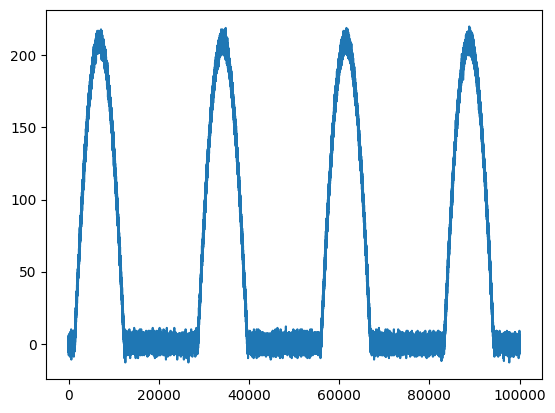

In [20]:
# This allows us to plot right here in the notebook
%matplotlib inline

# Hacking up a noisy pulse train
from matplotlib import pyplot as plt

n = 100000
noise = np.random.normal(size=n) * 3
pulses = np.maximum(np.sin(np.arange(n) / (n / 23)) - 0.3, 0.0)
waveform = ((pulses * 300) + noise).astype(np.int16)
plt.plot(waveform)

Тепер задекоруємо цю функцію `zero_suppress`, щоб вона виконувалась як векторизована ufunc на CUDA-пристрої.

In [25]:
# декоратор
def zero_suppress(waveform_value, threshold):
    if waveform_value < threshold:
        result = 0
    else:
        result = waveform_value
    return result

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


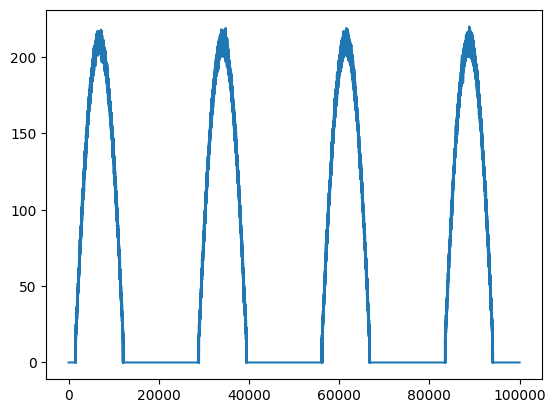

In [26]:
# This will throw an error until you successfully vectorize the `zero_suppress` function above.
# The noise on the baseline should disappear when zero_suppress is implemented
plt.plot(zero_suppress(waveform, 15))

## Керування пам'яттю GPU

До цього моменту ми використовували масиви NumPy на CPU як вхідні та вихідні дані для наших GPU-функцій. Для зручності Numba автоматично переносила ці дані на GPU, щоб GPU міг їх обробляти. При такому неявному перенесенні даних Numba, діючи консервативно, автоматично повертає дані назад на CPU після обробки. Як можна здогадатися, це дуже витратна за часом операція.

[Посібник з найкращих практик CUDA](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/index.html) зазначає:


> **Мінімізуйте передачу даних між хостом і пристроєм**, навіть якщо це означає запуск деяких ядер на пристрої, які не демонструють приросту продуктивності порівняно з виконанням на CPU хоста.

З огляду на це, варто подумати про те, як запобігти автоматичному поверненню даних на хост, щоб мати змогу виконувати додаткову роботу з даними і платити ціну копіювання назад на хост лише тоді, коли ми дійсно готові.

Спосіб зробити це — створити CUDA Device Arrays і передавати їх до наших GPU-функцій. Device arrays не будуть автоматично повертатися на хост після обробки, і ми можемо повторно використовувати їх на пристрої перш ніж, зрештою і лише за потреби, надіслати їх або їх частини назад на хост.


Для демонстрації розглянемо приклад з додавання і ufunc:


In [27]:
@vectorize(['float32(float32, float32)'], target='cuda')
def add_ufunc(x, y):
    return x + y

In [28]:
n = 100000
x = np.arange(n).astype(np.float32)
y = 2 * x

In [29]:
%timeit add_ufunc(x, y)  # Baseline performance with host arrays

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


1.27 ms ± 110 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Модуль `numba.cuda` містить функцію, яка копіює дані з хоста на GPU і повертає `CUDA device array`. Зверніть увагу, що коли ми намагаємося вивести вміст `device array`, ми отримуємо лише інформацію про масив, а не його фактичний вміст. Це пояснюється тим, що дані знаходяться на пристрої, і для виведення їх значень нам потрібно було б перенести їх назад на хост — як це зробити, буде показано пізніше:


In [30]:
from numba import cuda

x_device = cuda.to_device(x)
y_device = cuda.to_device(y)

print(x_device)
print(x_device.shape)
print(x_device.dtype)

(100000,)
float32


`Device arrays` можна передавати до CUDA-функцій так само, як і масиви NumPy, але без накладних витрат на копіювання:

In [31]:
%timeit add_ufunc(x_device, y_device)

307 µs ± 8.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)




Оскільки `x_device` та `y_device` вже знаходяться на пристрої, цей бенчмарк працює значно швидше.

Однак ми все ще виділяємо` device array` для виведення результату ufunc і копіюємо його назад на хост, навіть попри те, що в комірці вище ми фактично не присвоюємо масив жодній змінній. Щоб уникнути цього, можна створити вихідний масив за допомогою функції [`numba.cuda.device_array()`](https://numba.pydata.org/numba-doc/dev/cuda-reference/memory.html#numba.cuda.device_array):


In [32]:
out_device = cuda.device_array(shape=(n,), dtype=np.float32)  # does not initialize the contents, like np.empty()

Після цього можна використати спеціальний аргумент `out` у ufunc, щоб вказати вихідний буфер:

In [33]:
%timeit add_ufunc(x_device, y_device, out=out_device)

193 µs ± 52.4 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


Цей виклик `add_ufunc` не передбачає жодного перенесення даних між хостом і пристроєм, тому працює найшвидше. Якщо і коли ми захочемо повернути `device array` до пам'яті хоста, можна скористатися методом `copy_to_host()`:

In [34]:
out_host = out_device.copy_to_host()
print(out_host[:10])

[ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]


Можливо, ви думаєте, що ми порівнюємо нерівнозначні речі, оскільки ми не враховували виклики `to_device` при використанні `device arrays`, хоча неявні передачі даних зараховуються до бенчмарку при використанні хост-масивів `a` та `b` — і ви маєте рацію. Звісно, наша функція `add_func` не є особливо придатною для GPU, як обговорювалося раніше. Вищенаведене було лише демонстрацією того, як можна усунути передачі даних.



> Обов'язково вимірюйте час передачі даних, досліджуючи, чи варто відправляти обчислення на GPU.

Крім того, Numba надає додаткові методи для керування пам'яттю пристрою та передачею даних — [перегляньте документацію](https://numba.pydata.org/numba-doc/dev/cuda/memory.html) для отримання повної інформації.

## Підсумок

Ми розглянули практичні приклади і отримали досвід:

- Використовуватання Numba для компіляції Python-функцій для CPU
- Прискорювати ufunc NumPy за допомогою GPU
- Прискорювати власноруч написані векторизовані функції за допомогою GPU
- Оптимізувати передачу даних між CPU-хостом і GPU-пристроєм

<a href="https://www.nvidia.com/dli"> <img src="https://github.com/YKochura/ac-kpi/blob/main/figures/lec8/DLI%20Header.png?raw=true" alt="Header" style="width: 400px;"/> </a>